# Question 3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Region,Product,Units_Sold,Revenue
0,2024-01,North,Laptop,152,252168
1,2024-01,North,Smartphone,398,594612
2,2024-01,North,Tablet,156,202020
3,2024-01,North,Headphones,238,296072
4,2024-01,North,Smartwatch,152,48792


In [3]:
df.isna().sum()

Date          0
Region        0
Product       0
Units_Sold    0
Revenue       0
dtype: int64

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
Year = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
Day = df["Date"].dt.day

In [6]:
df["Revenue_per_Unit"] = df["Revenue"]/df["Units_Sold"]
df.head()

,Date,Region,Product,Units_Sold,Revenue,Month,Revenue_per_Unit
0,2024-01-01,North,Laptop,152,252168,1,1659.0
1,2024-01-01,North,Smartphone,398,594612,1,1494.0
2,2024-01-01,North,Tablet,156,202020,1,1295.0
3,2024-01-01,North,Headphones,238,296072,1,1244.0
4,2024-01-01,North,Smartwatch,152,48792,1,321.0


In [7]:
#Find the top 3 products by total revenue.
df.groupby("Product").Revenue.sum()

Product
Headphones    13757810
Laptop        14464264
Smartphone    17045539
Smartwatch    15409987
Tablet        15803639
Name: Revenue, dtype: int64

In [8]:
#Calculate average monthly sales per region.
df.groupby("Region").Units_Sold.mean()

Region
East     288.850000
North    280.200000
South    274.666667
West     287.700000
Name: Units_Sold, dtype: float64

In [9]:
#Use groupby and agg to get total revenue and average units sold per product.
df.groupby("Product").agg({
    "Revenue" : "sum",
    "Units_Sold" : "mean"
})

,Revenue,Units_Sold
Product,,
Headphones,13757810,275.916667
Laptop,14464264,264.916667
Smartphone,17045539,296.791667
Smartwatch,15409987,290.312500
Tablet,15803639,286.333333


In [10]:
#Overall mean, median, and standard deviation of Revenue.
print(df["Revenue"].mean())
print(df["Revenue"].median())
print(df["Revenue"].std())

318671.82916666666
283092.0
221118.38050023356


In [11]:
#A NumPy array of Revenue_per_Unit for correlation analysis.
revenue_per_unit_array = df["Revenue_per_Unit"].to_numpy()
revenue_per_unit_array

array([1659., 1494., 1295., 1244.,  321.,  530., 1596., 1071.,  330.,
       1532.,  543., 1005., 1415.,  476.,  659.,  221.,  947., 1784.,
        710., 1699., 1175.,  389.,  886.,  762., 1790., 1031., 1708.,
        846., 1040., 1497.,  800.,  213.,  976.,  764., 1563., 1590.,
       1678.,  708.,  234., 1304., 1785., 1611., 1221.,  765., 1995.,
       1700.,  601., 1779.,  401., 1195., 1015.,  655., 1475.,  495.,
        919.,  537., 1276.,  416.,  387.,  692., 1380.,  264.,  720.,
       1352., 1695., 1362.,  591.,  618.,  578., 1713., 1217., 1251.,
        400.,  979., 1256.,  702., 1797., 1004.,  883.,  925., 1160.,
        812., 1685., 1992., 1441.,  597.,  994.,  406., 1777., 1684.,
       1798.,  942.,  763., 1957.,  430., 1878.,  740.,  724., 1922.,
       1309.,  777.,  756., 1212.,  995., 1843., 1563., 1554., 1729.,
       1696.,  389., 1608., 1506.,  832., 1172., 1482.,  909.,  848.,
       1900., 1457.,  863., 1597., 1831., 1915., 1720.,  763., 1733.,
       1609., 1336.,

Region
East     18494563
North    19569853
South    19292081
West     19124742
Name: Revenue, dtype: int64


<BarContainer object of 4 artists>

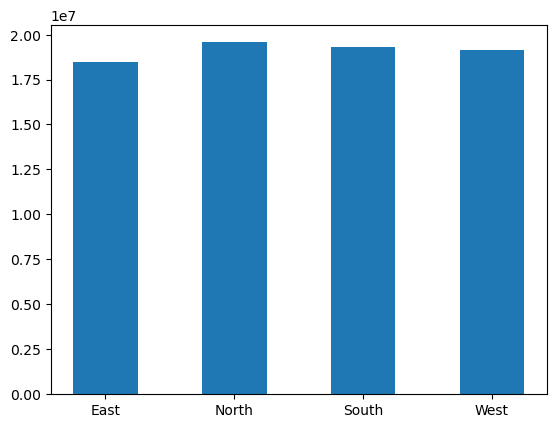

In [12]:
# Plot a bar chart of total revenue per region.
# Create a line plot showing monthly revenue trends.
# Plot a scatter plot of Units_Sold vs. Revenue, colored by Region.
total_revenue_per_region = df.groupby("Region").Revenue.sum()
print(total_revenue_per_region)
plt.bar(total_revenue_per_region.index,total_revenue_per_region,width=0.5)

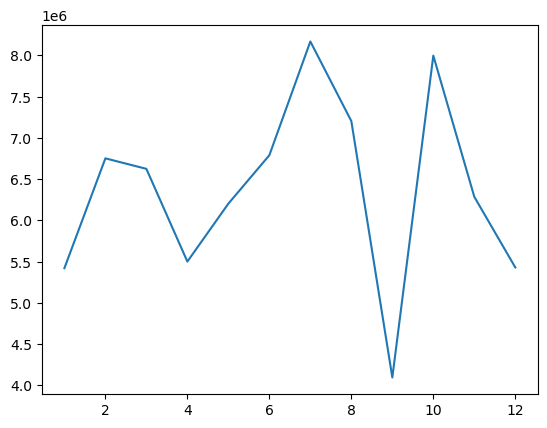

In [13]:
monthly_revenue = df.groupby("Month").Revenue.sum() 
plt.plot(monthly_revenue.index,monthly_revenue)

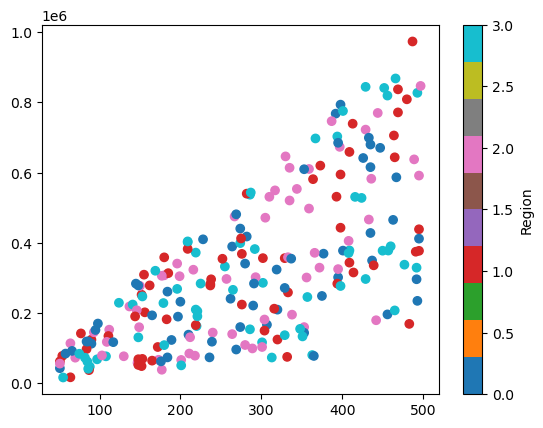

In [19]:
# Plot a scatter plot of Units_Sold vs. Revenue, colored by Region.
reg = df["Region"].astype("category").cat.codes
plt.scatter(
    df["Units_Sold"],
    df["Revenue"],
    c=reg,
    cmap="tab10"
)
plt.colorbar(label="Region")